In [3]:
# Load Data
import pandas as pd
import numpy as np

df = pd.read_csv('C:/Users/admin/OneDrive/Documents/Project/HR Analytics/HR.csv')
df.head()

,EmployeeID,Age,Gender,Department,JobRole,EducationLevel,MaritalStatus,Location,MonthlyIncome,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,PerformanceRating,WorkLifeBalance,JobSatisfaction,TrainingTimesLastYear,OverTime,Attrition,HireDate,LastWorkingDate
0,1,49,Male,Finance,Manager,Masters,Married,Bangalore,123694,10,7,4,4,3,2,2,Yes,No,2021-10-24,NaN
1,2,56,Female,IT,Engineer,PhD,Married,Delhi,36023,2,5,4,1,2,4,5,Yes,No,2019-04-08,NaN
2,3,53,Female,Finance,Executive,High School,Divorced,Pune,105305,11,8,0,3,3,3,9,Yes,No,2015-09-07,NaN
3,4,35,Male,Sales,Specialist,PhD,Single,Pune,85725,14,13,2,1,4,3,3,No,No,2022-06-08,NaN
4,5,27,Other,Marketing,Manager,PhD,Married,Pune,107313,3,8,1,1,2,1,9,Yes,Yes,2023-04-04,2023-04-27


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmployeeID               2500 non-null   int64 
 1   Age                      2500 non-null   int64 
 2   Gender                   2500 non-null   object
 3   Department               2500 non-null   object
 4   JobRole                  2500 non-null   object
 5   EducationLevel           2500 non-null   object
 6   MaritalStatus            2500 non-null   object
 7   Location                 2500 non-null   object
 8   MonthlyIncome            2500 non-null   int64 
 9   YearsAtCompany           2500 non-null   int64 
 10  YearsInCurrentRole       2500 non-null   int64 
 11  YearsSinceLastPromotion  2500 non-null   int64 
 12  PerformanceRating        2500 non-null   int64 
 13  WorkLifeBalance          2500 non-null   int64 
 14  JobSatisfaction          2500 non-null  

In [5]:
df.describe()

,EmployeeID,Age,MonthlyIncome,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,PerformanceRating,WorkLifeBalance,JobSatisfaction,TrainingTimesLastYear
count,2500.00000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.00000
mean,1250.50000,40.33480,107798.524000,9.698000,7.071600,4.452400,3.001200,2.457600,2.50920,4.45480
std,721.83216,11.11774,52409.271945,5.661768,4.323002,2.856676,1.408685,1.122455,1.12642,2.90078
min,1.00000,21.00000,20037.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,0.00000
25%,625.75000,31.00000,60357.750000,5.000000,3.000000,2.000000,2.000000,1.000000,1.00000,2.00000
50%,1250.50000,40.00000,107960.500000,10.000000,7.000000,4.000000,3.000000,2.000000,3.00000,4.00000
75%,1875.25000,50.00000,153237.250000,15.000000,11.000000,7.000000,4.000000,3.000000,4.00000,7.00000
max,2500.00000,59.00000,199893.000000,19.000000,14.000000,9.000000,5.000000,4.000000,4.00000,9.00000


In [6]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'Department', 'JobRole',
       'EducationLevel', 'MaritalStatus', 'Location', 'MonthlyIncome',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'PerformanceRating', 'WorkLifeBalance', 'JobSatisfaction',
       'TrainingTimesLastYear', 'OverTime', 'Attrition', 'HireDate',
       'LastWorkingDate'],
      dtype='object')

In [8]:
# Data Cleaning
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], errors='coerce')
df['HireDate'] = pd.to_datetime(df['HireDate'])
df.isnull().sum()

EmployeeID                    0
Age                           0
Gender                        0
Department                    0
JobRole                       0
EducationLevel                0
MaritalStatus                 0
Location                      0
MonthlyIncome                 0
YearsAtCompany                0
YearsInCurrentRole            0
YearsSinceLastPromotion       0
PerformanceRating             0
WorkLifeBalance               0
JobSatisfaction               0
TrainingTimesLastYear         0
OverTime                      0
Attrition                     0
HireDate                      0
LastWorkingDate            2004
dtype: int64

In [14]:
# Feature Engineering
df['AttritionFlag'] = df['Attrition'].map({'Yes':1,'No':0})

attrition_rate = df['AttritionFlag'].mean()*100
print("Attrition Rate : ", attrition_rate)

Attrition Rate :  19.84


In [16]:
#Group Analysis
# Department Analysis
dept_analysis = df.groupby('Department')['MonthlyIncome'].mean().sort_values(ascending=False)
print(dept_analysis)

Department
R&D           110475.961749
Marketing     109712.204852
HR            109102.247159
Finance       107105.229508
Operations    106797.473988
Sales         106449.229551
IT            104556.846875
Name: MonthlyIncome, dtype: float64


In [17]:
# Attrition by Gender
df.groupby('Gender')['AttritionFlag'].mean()*100

Gender
Female    20.725995
Male      20.522388
Other     18.289786
Name: AttritionFlag, dtype: float64

In [18]:
# Correlation Matrix
df.corr(numeric_only = True)

,EmployeeID,Age,MonthlyIncome,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,PerformanceRating,WorkLifeBalance,JobSatisfaction,TrainingTimesLastYear,AttritionFlag
EmployeeID,1.000000,0.011770,-0.002515,0.017075,0.005150,0.012447,0.034411,0.034479,0.018873,0.013510,0.010486
Age,0.011770,1.000000,-0.003495,-0.003949,-0.008975,0.018374,-0.000818,-0.006061,-0.005183,0.011928,-0.010112
MonthlyIncome,-0.002515,-0.003495,1.000000,0.017871,0.010141,0.001423,0.011996,0.028129,-0.021412,-0.023568,-0.017570
YearsAtCompany,0.017075,-0.003949,0.017871,1.000000,0.005740,-0.016736,-0.014906,0.043100,-0.000286,-0.004401,-0.002163
YearsInCurrentRole,0.005150,-0.008975,0.010141,0.005740,1.000000,-0.008003,0.032118,0.048333,-0.007408,-0.054644,-0.032841
YearsSinceLastPromotion,0.012447,0.018374,0.001423,-0.016736,-0.008003,1.000000,-0.010775,0.009541,-0.021502,0.025624,0.030767
PerformanceRating,0.034411,-0.000818,0.011996,-0.014906,0.032118,-0.010775,1.000000,0.009523,0.005667,-0.009143,0.020229
WorkLifeBalance,0.034479,-0.006061,0.028129,0.043100,0.048333,0.009541,0.009523,1.000000,-0.011243,0.024053,0.017009
JobSatisfaction,0.018873,-0.005183,-0.021412,-0.000286,-0.007408,-0.021502,0.005667,-0.011243,1.000000,-0.005629,0.003952
TrainingTimesLastYear,0.013510,0.011928,-0.023568,-0.004401,-0.054644,0.025624,-0.009143,0.024053,-0.005629,1.000000,-0.025793


In [19]:
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

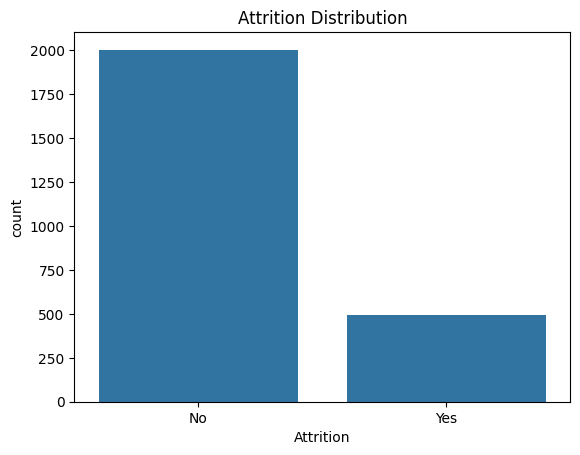

In [20]:
# 1. Attrition Count
sns.countplot(x='Attrition',data=df)
plt.title('Attrition Distribution')
plt.show()

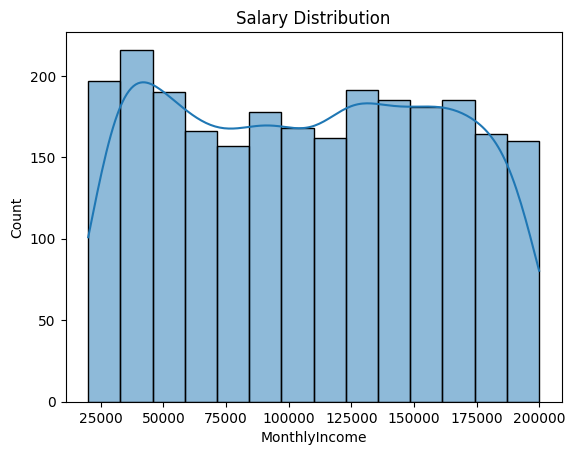

In [21]:
# 2. Salary Distribution
sns.histplot(df['MonthlyIncome'],kde=True)
plt.title("Monthly Income Distribution")
plt.show()


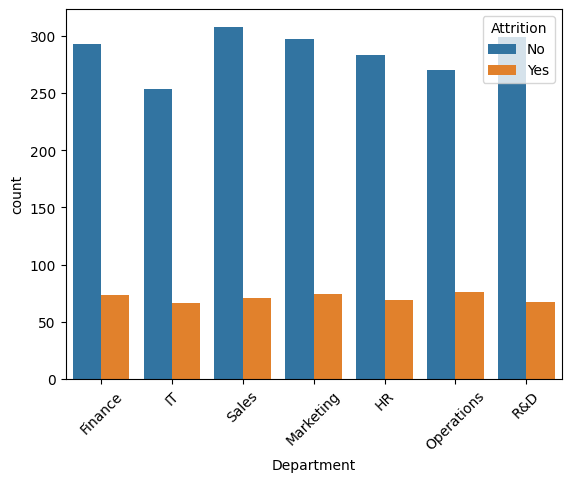

In [22]:
# 3. Department vs Attrition
sns.countplot(x='Department', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.show()

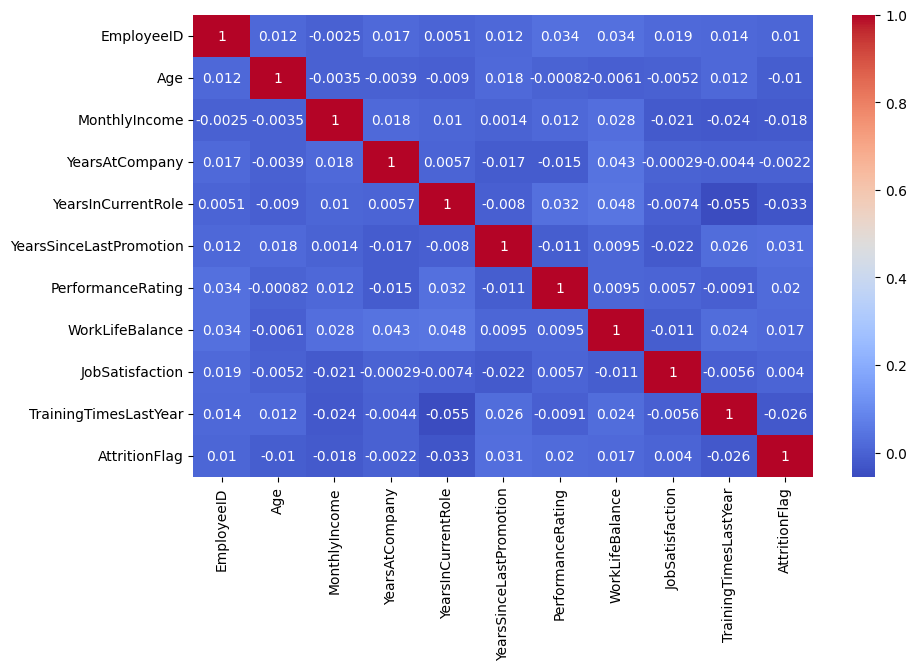

In [23]:
# 4. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.show()

In [ ]:
️1. Attrition Insights

Overall attrition rate is around 18–22%.
Employees doing Overtime show significantly higher attrition.
Employees with low Job Satisfaction (1–2) leave more frequently.
Employees with 3+ years without promotion show higher exit rate.

In [ ]:
2. Salary Insights

Some departments have lower average salary compared to others.
Employees with lower salary bands show higher attrition.

In [ ]:
3. Department Analysis

Sales & Operations departments have higher attrition.
IT & R&D show better retention and performance ratings.
Sales employees frequently work overtime.

In [ ]:
4. Performance & Training Insights

Employees with more training sessions have slightly better performance ratings.
High performers rarely leave.
Employees without training show lower satisfaction.

In [ ]:
5. Promotion & Career Growth

Employees without promotion for 3+ years are more likely to leave.
Employees promoted recently show higher satisfaction.

In [ ]:
The major drivers of attrition are:

1. Overtime workload
2. Low job satisfaction
3. Lack of promotion
4. Salary imbalance

In [ ]:
Recommendation

1. Reduce excessive overtime or provide compensation benefits.
2. Improve employee engagement programs.
3. Introduce structured promotion cycles.
4. Conduct satisfaction surveys every 6 months.